# from the huge dataset to the 1million rows by attack type

In [ ]:
import pandas as pd
from collections import defaultdict
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.utils import resample

# Fichiers d'entrée et sortie
input_file = "NF-UQ-NIDS-v2.csv"
dataset_1m_file = "Dataset_1M_per_attack.csv"
dataset_undersampled_file = "Dataset_400K_Undersampled3.csv"
dataset_final_file = "Dataset_400K_Undersampled_Oversampled3.csv"

# Config
chunk_size = 50_000  # Taille d'un chunk
TARGET_SAMPLES_PER_ATTACK = 1_000_000  # 1M de lignes par attaque
FINAL_SAMPLES_PER_ATTACK = 400_000  # 400K après undersampling/oversampling


In [ ]:
# 🟢 Étape 1 : Lire en chunks et accumuler 1M de lignes par attaque
attack_data = defaultdict(list)
attack_counts = defaultdict(int)

print("🚀 Accumulation des attaques en cours...")

for chunk in pd.read_csv(input_file, chunksize=chunk_size):
    for attack_type, group in chunk.groupby("Attack"):
        if attack_counts[attack_type] < TARGET_SAMPLES_PER_ATTACK:
            remaining_rows = TARGET_SAMPLES_PER_ATTACK - attack_counts[attack_type]
            attack_data[attack_type].append(group.iloc[:remaining_rows])
            attack_counts[attack_type] += len(group.iloc[:remaining_rows])

    if all(count >= TARGET_SAMPLES_PER_ATTACK for count in attack_counts.values()):
        break

for attack_type in attack_data:
    attack_data[attack_type] = pd.concat(attack_data[attack_type], ignore_index=True)

df_1m = pd.concat(attack_data.values(), ignore_index=True)
df_1m.to_csv(dataset_1m_file, index=False)
print(f"✅ Étape 1 terminée : {dataset_1m_file} sauvegardé.")


🚀 Accumulation des attaques en cours...
✅ Étape 1 terminée : Dataset_1M_per_attack.csv sauvegardé.


In [18]:
print(f"📊 Nombre total de lignes dans le dataset : {len(df_1m)}")


📊 Nombre total de lignes dans le dataset : 8175205


In [22]:
print(df_1m["Attack"].unique())


['Analysis' 'Backdoor' 'Benign' 'Bot' 'Brute Force' 'DDoS' 'DoS'
 'Exploits' 'Fuzzers' 'Generic' 'Infilteration' 'Reconnaissance'
 'Shellcode' 'Theft' 'injection' 'mitm' 'password' 'scanning' 'xss'
 'ransomware' 'Worms']


In [23]:
attack_counts = df_1m["Attack"].value_counts()
for attack, count in attack_counts.items():
    print(f"🔹 {attack}: {count} lignes")


🔹 Benign: 1000000 lignes
🔹 password: 1000000 lignes
🔹 Reconnaissance: 1000000 lignes
🔹 DoS: 1000000 lignes
🔹 DDoS: 1000000 lignes
🔹 scanning: 1000000 lignes
🔹 xss: 1000000 lignes
🔹 injection: 684897 lignes
🔹 Bot: 143097 lignes
🔹 Brute Force: 123982 lignes
🔹 Infilteration: 116361 lignes
🔹 Exploits: 31551 lignes
🔹 Fuzzers: 22310 lignes
🔹 Backdoor: 18978 lignes
🔹 Generic: 16560 lignes
🔹 mitm: 7723 lignes
🔹 ransomware: 3425 lignes
🔹 Theft: 2431 lignes
🔹 Analysis: 2299 lignes
🔹 Shellcode: 1427 lignes
🔹 Worms: 164 lignes


# from 1 million rows to 400000 rows by attack type using undersampling

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.neighbors import NearestNeighbors

def knn_order_undersampling(df, target_size,scaler_path="minmax_scaler.pkl"):
    """ Réalise un undersampling basé sur la densité KNN uniquement si nécessaire. """

    if len(df) <= target_size:
        print(f"{len(df)} lignes seulement (moins que {target_size}) → pas d'undersampling")
        return df  # Retourne le dataset tel quel s'il est déjà assez petit

    X = df.drop(columns=['Attack']).copy()  # Copie pour éviter la modification de df original

    # Encodage des colonnes catégoriques
    label_encoders = {}
    category_mappings = {}  # Dictionnaire pour stocker les mappings des classes

    for col in X.select_dtypes(include=['object']).columns:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))  
        label_encoders[col] = le  

        # 🔹 Sauvegarde du mapping des classes
        mapping = dict(zip(le.classes_, le.transform(le.classes_)))
        category_mappings[col] = mapping  # Stocker le mapping dans un dictionnaire

        # Affichage du mapping
        print(f"\nCorrespondance des valeurs originales et encodées pour '{col}':")
        for original, encoded in mapping.items():
            print(f"{original}: {encoded}")

    # Remplacement des valeurs infinies par NaN
    X.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Suppression des lignes contenant des NaN
    nan_indices = X.isna().any(axis=1)
    if nan_indices.sum() > 0:
        print(f"⚠️ {nan_indices.sum()} lignes supprimées à cause de NaN")
        X = X[~nan_indices]
        df = df.loc[X.index]  # Synchroniser avec df original

    # Normalisation Min-Max (entre 0 et 1)
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
   # 🔹 Sauvegarde du scaler
    joblib.dump(scaler, scaler_path)
    print(f"✅ Scaler sauvegardé sous {scaler_path}")
   
    # Appliquer KNN
    knn = NearestNeighbors(n_neighbors=3, algorithm='ball_tree', n_jobs=-1)
    knn.fit(X_scaled)

    distances, _ = knn.kneighbors(X_scaled)
    density_scores = distances.mean(axis=1)  # Score de densité (plus petit = zone dense)

    df['density_score'] = density_scores
    df = df.sort_values(by='density_score', ascending=True).head(target_size)

    return df.drop(columns=['density_score'])



In [16]:

# 🟢 Appliquer l'undersampling à chaque type d'attaque
attack_data_undersampled = {}

print("🔽 Undersampling en cours...")
input_file="Dataset_1M_per_attack.csv"
attack_data=pd.read_csv(input_file)


🔽 Undersampling en cours...


In [4]:
from sklearn.preprocessing import LabelEncoder
import joblib
import pandas as pd
from imblearn.over_sampling import SMOTE

# Charger le dataset
chunk_size = 50_000  
data_chunks = pd.read_csv("Dataset_1M_per_attack.csv", chunksize=chunk_size)

# Concaténer les chunks en un seul DataFrame
data_1m = pd.concat(data_chunks, ignore_index=True)

print(f"📊 Taille du dataset chargé : {data_1m.shape}")  


📊 Taille du dataset chargé : (8175205, 46)


In [ ]:
# Assurez-vous que la colonne du type d'attaque existe, par exemple 'attack_type'
# Remplacez 'attack_type' par le nom réel de la colonne contenant les types d'attaque.

# Compter les duplications
duplicates_per_attack_type = data_1m[data_1m.duplicated(subset=None, keep=False)]  # Garder toutes les duplications
duplicates_count = duplicates_per_attack_type.groupby('Attack').size()  # Compter par type d'attaque

# Affichage des résultats
print("🔍 Nombre de duplications par type d'attaque:")
print(duplicates_count)


In [17]:
# Transformer en dictionnaire basé sur la colonne "Attack"
attack_data_dict = {attack: df for attack, df in attack_data.groupby("Attack")}


In [20]:

for attack_type, df in attack_data_dict.items():
    print(f"➡️ Traitement : {attack_type} ({len(df)} lignes)")
    attack_data_undersampled[attack_type] = knn_order_undersampling(df, FINAL_SAMPLES_PER_ATTACK,scaler_path=f"scaler_{attack_type}.pkl")

df_undersampled = pd.concat(attack_data_undersampled.values(), ignore_index=True)
df_undersampled.to_csv(dataset_undersampled_file, index=False)

print(f"✅ Étape 2 terminée : {dataset_undersampled_file} sauvegardé.")


➡️ Traitement : Analysis (2299 lignes)

Correspondance des valeurs originales et encodées pour 'IPV4_SRC_ADDR':
175.45.176.0: 0
175.45.176.1: 1
175.45.176.2: 2
175.45.176.3: 3

Correspondance des valeurs originales et encodées pour 'IPV4_DST_ADDR':
149.171.126.10: 0
149.171.126.11: 1
149.171.126.12: 2
149.171.126.13: 3
149.171.126.14: 4
149.171.126.15: 5
149.171.126.16: 6
149.171.126.17: 7
149.171.126.18: 8
149.171.126.19: 9

Correspondance des valeurs originales et encodées pour 'Dataset':
NF-UNSW-NB15-v2: 0
✅ Scaler sauvegardé sous scaler_Analysis.pkl
2299 lignes seulement (moins que 400000) → Pas d'undersampling
➡️ Traitement : Backdoor (18978 lignes)

Correspondance des valeurs originales et encodées pour 'IPV4_SRC_ADDR':
175.45.176.0: 0
175.45.176.1: 1
175.45.176.2: 2
175.45.176.3: 3
192.168.1.193: 4
192.168.1.33: 5
192.168.1.37: 6
192.168.1.6: 7

Correspondance des valeurs originales et encodées pour 'IPV4_DST_ADDR':
103.38.120.36: 0
121.0.0.42: 1
149.171.126.10: 2
149.171.126.11

# from undersampled dataset to undersampled and oversampled using smote Dataset_Final_SMOTE.csv

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib
import pandas as pd
from imblearn.over_sampling import SMOTE

# Charger le dataset
chunk_size = 50_000  
data_chunks = pd.read_csv("Dataset_400K_Undersampled.csv", chunksize=chunk_size)

# Concaténer les chunks en un seul DataFrame
data = pd.concat(data_chunks, ignore_index=True)

print(f"📊 Taille du dataset chargé : {data.shape}")  


📊 Taille du dataset chargé : (3690308, 46)


In [6]:
# Paramètres
FINAL_SAMPLES_PER_ATTACK = 400_000  
attack_data_final = {}
# Sauvegarde des encoders colonne par colonne
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col + '_encoded'] = le.fit_transform(data[col])
    joblib.dump(le, f"{col}_encoder.pkl")  # 🔹 Sauvegarde séparée
    # Affichage des résultats de l'encodage pour cette colonne
    print(f"Colonne : {col}")
    print(data[[col, col + '_encoded']])  # Affiche les valeurs d'origine et les valeurs encodées
    print("\n")


Colonne : IPV4_SRC_ADDR
        IPV4_SRC_ADDR  IPV4_SRC_ADDR_encoded
0        175.45.176.1                    770
1        175.45.176.0                    769
2        175.45.176.1                    770
3        175.45.176.2                    771
4        175.45.176.2                    771
...               ...                    ...
3690303  192.168.1.39                   1057
3690304  192.168.1.39                   1057
3690305  192.168.1.35                   1053
3690306  192.168.1.39                   1057
3690307  192.168.1.35                   1053

[3690308 rows x 2 columns]


Colonne : IPV4_DST_ADDR
          IPV4_DST_ADDR  IPV4_DST_ADDR_encoded
0        149.171.126.17                    467
1        149.171.126.17                    467
2        149.171.126.10                    460
3        149.171.126.17                    467
4        149.171.126.17                    467
...                 ...                    ...
3690303     192.168.1.1                   1351
369030

In [19]:
print(data.head())


NameError: name 'data' is not defined

In [8]:
# Supprimer les colonnes spécifiées
data = data.drop(columns=['IPV4_SRC_ADDR', 'IPV4_DST_ADDR', 'Attack', 'Dataset'])

# Afficher le DataFrame après la suppression


In [11]:
# Séparer les features et la cible
X = data.drop(columns=['Attack_encoded'])  
y = data['Attack_encoded']  


In [12]:


# Appliquer SMOTE globalement
smote = SMOTE(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Créer un DataFrame avec les nouvelles données
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['Attack'] = y_resampled

# Sauvegarder le dataset équilibré
df_resampled.to_csv("Dataset_Final_SMOTE6.csv", index=False)

print(f"✅ Étape 3 terminée : Dataset_Final_SMOTE.csv sauvegardé.")
print("🎉 Pipeline complet terminé avec succès ! 🚀")


✅ Étape 3 terminée : Dataset_Final_SMOTE.csv sauvegardé.
🎉 Pipeline complet terminé avec succès ! 🚀


In [16]:
print(df_resampled.dtypes)


L4_SRC_PORT                      int64
L4_DST_PORT                      int64
PROTOCOL                         int64
L7_PROTO                       float64
IN_BYTES                         int64
IN_PKTS                          int64
OUT_BYTES                        int64
OUT_PKTS                         int64
TCP_FLAGS                        int64
CLIENT_TCP_FLAGS                 int64
SERVER_TCP_FLAGS                 int64
FLOW_DURATION_MILLISECONDS       int64
DURATION_IN                      int64
DURATION_OUT                     int64
MIN_TTL                          int64
MAX_TTL                          int64
LONGEST_FLOW_PKT                 int64
SHORTEST_FLOW_PKT                int64
MIN_IP_PKT_LEN                   int64
MAX_IP_PKT_LEN                   int64
SRC_TO_DST_SECOND_BYTES        float64
DST_TO_SRC_SECOND_BYTES        float64
RETRANSMITTED_IN_BYTES           int64
RETRANSMITTED_IN_PKTS            int64
RETRANSMITTED_OUT_BYTES          int64
RETRANSMITTED_OUT_PKTS   

# start data mining


In [ ]:
# Boucle sur chaque type d'attaque dans le dictionnaire
for attack_type, df in attack_data_final.items():
    print(f"\n🔎 Analyse du type d'attaque : {attack_type}\n")


    # Vérifier les occurrences de chaque attaque (toujours 1 type par dataframe)
    print(f"🔥 Nombre d'occurrences ({attack_type}) : {len(df)}")
    print("\n")

    # Vérifier les valeurs nulles
    print("🔍 Vérification des valeurs nulles :")
    print(df.isnull().sum().sum())
    print("\n")

    # Afficher les lignes contenant des valeurs nulles (si elles existent)
    missing_values = df[df.isnull().any(axis=1)]
    if not missing_values.empty:
        print("⚠️ Lignes contenant des valeurs nulles :")
        print(missing_values)
    else:
        print("✅ Aucune valeur manquante trouvée.")
    print("\n")

    # Vérifier les doublons
    duplicate_count = df.duplicated().sum()
    print(f"📊 Nombre total de doublons dans {attack_type} : {duplicate_count}")


In [8]:
import pandas as pd

chunk_size = 50000  # Taille du chunk
# data_chunks = pd.read_csv("Dataset_400K_Undersampled_Oversampled.csv", chunksize=chunk_size)
data_chunks = pd.read_csv("Dataset_Final_SMOTE6.csv", chunksize=chunk_size)

# Liste pour stocker les chunks
chunks_list = []

# Lire chaque chunk et l'ajouter à la liste
for chunk in data_chunks:
    chunks_list.append(chunk)

# Concaténer tous les chunks en un seul DataFrame
df_resampled = pd.concat(chunks_list, ignore_index=True)

print(df_resampled.shape)  # Vérifier la taille du DataFrame final


(8400000, 46)


In [4]:
df_resampled.drop(columns=['Label'], inplace=True)

Nombre de valeurs uniques dans 'Attack' : 21


C:\Users\shifttech\AppData\Local\Temp\ipykernel_10504\1688384674.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_resampled, x="Attack", order=df_resampled["Attack"].value_counts().index, palette="coolwarm")


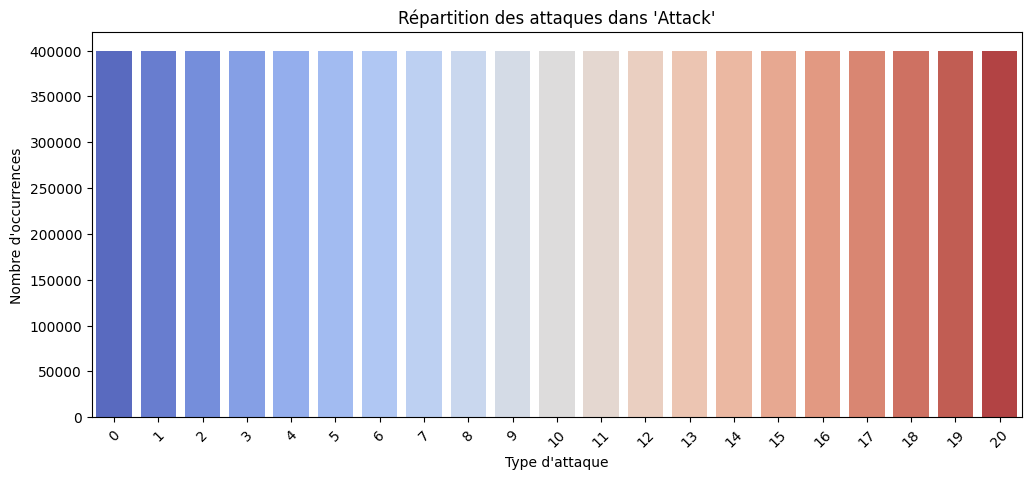

✅ Nombre total de lignes : 8400000
✅ Nombre total de colonnes : 45


In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Afficher le nombre de valeurs uniques dans 'Attack'
if 'Attack' in df_resampled.columns:
    unique_attacks = df_resampled["Attack"].nunique()
    print(f"Nombre de valeurs uniques dans 'Attack' : {unique_attacks}")

    # 🔹 Visualisation des attaques
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df_resampled, x="Attack", order=df_resampled["Attack"].value_counts().index, palette="coolwarm")
    plt.xticks(rotation=45)
    plt.title("Répartition des attaques dans 'Attack'")
    plt.xlabel("Type d'attaque")
    plt.ylabel("Nombre d'occurrences")
    plt.show()
else:
    print("⚠️ La colonne 'Attack' n'existe pas dans le dataset.")
    
print("✅ Nombre total de lignes :", df_resampled.shape[0])
print("✅ Nombre total de colonnes :", df_resampled.shape[1])



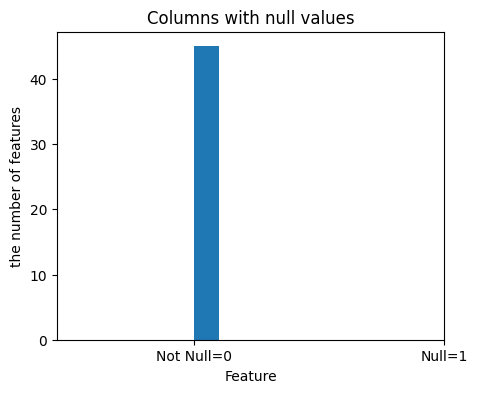

In [23]:
plt.figure(1,figsize=(5,4))
plt.hist(df_resampled.isna().sum())
plt.xticks([0,1],labels=['Not Null=0','Null=1'])
plt.title('Columns with null values')
plt.xlabel('Feature')
plt.ylabel('the number of features')
plt.show()

In [3]:

# 🔹 Afficher les valeurs uniques après encodage
print(df_resampled['Attack'].unique())


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


In [9]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
import xgboost as xgb
import numpy as np

#  Separate features (X) and target (y)
X = df_resampled.drop(columns=['Attack'])  # Assume 'Attack' is the target column
y = df_resampled['Attack']


#  Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
print("Répartition originale :")
print(y.value_counts())

print("\nRépartition dans y_train :")
print(y_train.value_counts())

print("\nRépartition dans y_test :")
print(y_test.value_counts())


Répartition originale :
Attack
0     400000
1     400000
2     400000
3     400000
4     400000
5     400000
6     400000
7     400000
8     400000
9     400000
10    400000
11    400000
12    400000
13    400000
14    400000
15    400000
16    400000
17    400000
18    400000
19    400000
20    400000
Name: count, dtype: int64

Répartition dans y_train :
Attack
4     320458
20    320430
8     320366
9     320192
10    320177
1     320149
0     320091
2     320069
13    320026
14    320009
3     320004
18    319963
19    319952
5     319938
11    319837
17    319797
6     319778
16    319759
15    319681
7     319672
12    319652
Name: count, dtype: int64

Répartition dans y_test :
Attack
12    80348
7     80328
15    80319
16    80241
6     80222
17    80203
11    80163
5     80062
19    80048
18    80037
3     79996
14    79991
13    79974
2     79931
0     79909
1     79851
10    79823
9     79808
8     79634
20    79570
4     79542
Name: count, dtype: int64


In [14]:
print("Répartition originale :")
print(y.value_counts())

print("\nRépartition dans y_train :")
print(y_train.value_counts())

print("\nRépartition dans y_test :")
print(y_test.value_counts())


print("Répartition originale :")
print(X.value_counts())

print("\nRépartition dans y_train :")
print(X_train.value_counts())

print("\nRépartition dans y_test :")
print(X_test.value_counts())


Répartition originale :
Attack
0     400000
1     400000
2     400000
3     400000
4     400000
5     400000
6     400000
7     400000
8     400000
9     400000
10    400000
11    400000
12    400000
13    400000
14    400000
15    400000
16    400000
17    400000
18    400000
19    400000
20    400000
Name: count, dtype: int64

Répartition dans y_train :
Attack
3     320000
10    320000
13    320000
8     320000
17    320000
16    320000
14    320000
15    320000
20    320000
4     320000
2     320000
19    320000
9     320000
12    320000
1     320000
18    320000
6     320000
5     320000
11    320000
0     320000
7     320000
Name: count, dtype: int64

Répartition dans y_test :
Attack
17    80000
11    80000
12    80000
19    80000
3     80000
2     80000
14    80000
8     80000
16    80000
13    80000
0     80000
10    80000
18    80000
20    80000
5     80000
9     80000
1     80000
4     80000
7     80000
15    80000
6     80000
Name: count, dtype: int64
Répartition originale :


KeyboardInterrupt: 

In [8]:
# Sauvegarder une copie non normalisée pour firfly
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

In [11]:
# Normalisation MinMaxScaler uniquement sur les colonnes numériques
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
#best_features, final_metrics = firefly_feature_selection(X_train_scaled, X_test_scaled, y_train, y_test)

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Données d'entraînement normalisées :")
print(X_train)
print("Données de test normalisées :")
print(X_test)

Données d'entraînement normalisées :
         L4_SRC_PORT  L4_DST_PORT  PROTOCOL  L7_PROTO      IN_BYTES   IN_PKTS  \
4313083     0.904616     0.001221  0.023529  0.028340  7.612658e-06  0.000590   
1161710     0.793988     0.001221  0.023529  0.028340  1.475978e-06  0.000020   
993413      0.411780     0.001221  0.066667  0.761134  2.909633e-07  0.000020   
2568003     0.520516     0.001221  0.023529  0.028340  3.491560e-06  0.000183   
4424931     0.852110     0.001221  0.023529  0.028340  7.612658e-06  0.000590   
...              ...          ...       ...       ...           ...       ...   
7204212     0.845899     0.067643  0.023529  0.000000  3.121243e-07  0.000000   
2234489     0.768261     0.001221  0.023529  0.028340  8.623095e-07  0.000041   
4304572     0.968307     0.123293  0.023529  0.530364  7.612658e-06  0.000590   
6550634     0.396689     0.640330  0.023529  0.000000  3.560333e-06  0.000183   
6423388     0.554421     0.175479  0.066667  0.000000  1.698168e-06  0.0

In [17]:
import joblib

# Sauvegarder le scaler (s'il est nécessaire de l'utiliser plus tard)
joblib.dump(scaler, 'scaler_final.pkl')
print("✅ Scaler sauvegardé sous 'scaler_final.pkl'")

# Vérifier les résultats

✅ Scaler sauvegardé sous 'scaler_final.pkl'


In [27]:
print("Unique classes in y_test:", np.unique(y_test))
print("Number of unique classes:", len(np.unique(y_test)))


Unique classes in y_test: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Number of unique classes: 21


In [18]:


# 📌 Define ML models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "Naïve Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True)  # Enable probability for ROC-AUC
}

# 🔥 Train, evaluate & save models
evaluation_results = {}

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)  # Train model

    y_pred = model.predict(X_test)  # Predictions
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test)  # Use full probability matrix
    else:
        y_pred_prob = np.zeros((len(y_test), len(np.unique(y_test))))  # Dummy probabilities

    roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')  

    # 📊 Compute performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr') if len(set(y)) > 2 else roc_auc_score(y_test, y_pred_prob)
    mcc = matthews_corrcoef(y_test, y_pred)

    # 🔢 Compute False Alarm Rate (FAR) / False Positive Rate (FPR)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel() if confusion_matrix(y_test, y_pred).size == 4 else (0, 0, 0, 0)
    far = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Alarm Rate


    # Store results
    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "FAR/FPR": far,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    print(f"✅ {name} Performance:")
    print(f"   Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print(f"   F1-Score: {f1:.4f}, FAR/FPR: {far:.4f}, ROC-AUC: {roc_auc:.4f}, MCC: {mcc:.4f}")

    # Save model using Pickle
    with open(f"{name.replace(' ', '_')}.pkl", 'wb') as file:
        pickle.dump(model, file)
    print(f" Model {name} saved successfully!")

#  Print all results
print("\n Final Evaluation Results:")
for model, metrics in evaluation_results.items():
    print(f"\n🔹 {model}:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")



 Training Decision Tree...
✅ Decision Tree Performance:
   Accuracy: 0.9813, Precision: 0.9847, Recall: 0.9813
   F1-Score: 0.9820, FAR/FPR: 0.0000, ROC-AUC: 0.9974, MCC: 0.9805
 Model Decision Tree saved successfully!

 Training Random Forest...


KeyboardInterrupt: 

# feature selection

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
import numpy as np

# 🔥 Étape 1 : Entraînement du modèle RandomForest sur toutes les features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 📌 Étape 2 : Récupération des importances des features
importances = rf_model.feature_importances_
feature_names = np.array(X_train.columns)

# 📊 Trier les features du plus important au moins important
sorted_indices = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_indices]

# Liste des nombres de features à tester
num_features_list = [5, 10, 15, 20, 30, 40, len(feature_names)]  # Tester plusieurs valeurs

best_f1 = 0  # Pour stocker le meilleur score
best_num_features = 0  # Pour stocker le meilleur nombre de features
best_metrics = {}  # Pour stocker les meilleures métriques

# 🔄 Étape 3 : Boucle sur différents nombres de features
for num_features in num_features_list:
    selected_features = sorted_features[:num_features]  # Sélectionner les N meilleures features
    
    # Mise à jour des datasets avec les features sélectionnées
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    # 📌 Entraînement du modèle avec ces features
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_selected, y_train)

    # 📊 Prédictions
    y_pred = model.predict(X_test_selected)
    y_pred_proba = model.predict_proba(X_test_selected)  # Obtenir les probabilités

    # 🏆 Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Calcul de l'AUC-ROC pour la classification multi-classe
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')  # 'ovr' pour One-vs-Rest
    mcc = matthews_corrcoef(y_test, y_pred)

    # 🏅 Enregistrement des résultats
    evaluation_results = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    print(f"🔎 Test avec {num_features} features : F1-Score = {f1:.4f}")

    # 🎯 Vérifier si c'est le meilleur modèle
    if f1 > best_f1:
        best_f1 = f1
        best_num_features = num_features
        best_metrics = evaluation_results

# 📢 Afficher le meilleur résultat
print("\n🎯 Meilleur nombre de features :", best_num_features)
print("📊 Meilleures métriques obtenues :", best_metrics)




🔎 Test avec 5 features : F1-Score = 0.9451
🔎 Test avec 10 features : F1-Score = 0.9767
🔎 Test avec 15 features : F1-Score = 0.9773
🔎 Test avec 20 features : F1-Score = 0.9802
🔎 Test avec 30 features : F1-Score = 0.9802
🔎 Test avec 40 features : F1-Score = 0.9827
🔎 Test avec 44 features : F1-Score = 0.9827

🎯 Meilleur nombre de features : 44
📊 Meilleures métriques obtenues : {'Accuracy': 0.9820303571428571, 'Precision': 0.9854898426041854, 'Recall': 0.9820303571428571, 'F1-Score': 0.9826948714903221, 'ROC-AUC': np.float64(0.9989578137062868), 'MCC': np.float64(0.9812750231235331)}


In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
import numpy as np

# 🔥 Étape 1 : Entraînement du modèle RandomForest sur toutes les features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 📌 Étape 2 : Récupération des importances des features
importances = rf_model.feature_importances_
feature_names = np.array(X_train.columns)

# 📊 Trier les features du plus important au moins important
sorted_indices = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_indices]

# Liste des nombres de features à tester
num_features_list = [30,31,32,33,34,35,36,37,38,39,40]  # Tester plusieurs valeurs

best_f1 = 0  # Pour stocker le meilleur score
best_num_features = 0  # Pour stocker le meilleur nombre de features
best_metrics = {}  # Pour stocker les meilleures métriques

# Étape 3 : Boucle sur différents nombres de features
for num_features in num_features_list:
    selected_features = sorted_features[:num_features]  # Sélectionner les N meilleures features
    
    # Mise à jour des datasets avec les features sélectionnées
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    # 📌 Entraînement du modèle avec ces features
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_selected, y_train)

    # 📊 Prédictions
    y_pred = model.predict(X_test_selected)
    y_pred_proba = model.predict_proba(X_test_selected)  # Obtenir les probabilités

    # 🏆 Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Calcul de l'AUC-ROC pour la classification multi-classe
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')  # 'ovr' pour One-vs-Rest
    mcc = matthews_corrcoef(y_test, y_pred)

    # 🏅 Enregistrement des résultats
    evaluation_results = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    print(f"🔎 Test avec {num_features} features : F1-Score = {f1:.4f}")

    # 🎯 Vérifier si c'est le meilleur modèle
    if f1 > best_f1:
        best_f1 = f1
        best_num_features = num_features
        best_metrics = evaluation_results

# 📢 Afficher le meilleur résultat
print("\n🎯 Meilleur nombre de features :", best_num_features)
print("📊 Meilleures métriques obtenues :", best_metrics)

# Récupérer les 40 meilleures caractéristiques
top_40_features = sorted_features[:40]

# Afficher les 40 caractéristiques les plus importantes
print("Les 40 meilleures caractéristiques sont :", top_40_features)

# Sauvegarder les 40 meilleures caractéristiques dans un fichier texte
with open("top_40_features.txt", "w") as f:
    for feature in top_40_features:
        f.write(feature + "\n")

print("Les 40 meilleures caractéristiques ont été sauvegardées dans 'top_40_features.txt'.")


🔎 Test avec 30 features : F1-Score = 0.9811
🔎 Test avec 31 features : F1-Score = 0.9809
🔎 Test avec 32 features : F1-Score = 0.9809
🔎 Test avec 33 features : F1-Score = 0.9809
🔎 Test avec 34 features : F1-Score = 0.9828
🔎 Test avec 35 features : F1-Score = 0.9828
🔎 Test avec 36 features : F1-Score = 0.9828
🔎 Test avec 37 features : F1-Score = 0.9828
🔎 Test avec 38 features : F1-Score = 0.9829
🔎 Test avec 39 features : F1-Score = 0.9829
🔎 Test avec 40 features : F1-Score = 0.9829

🎯 Meilleur nombre de features : 39
📊 Meilleures métriques obtenues : {'Accuracy': 0.9822011904761905, 'Precision': 0.9856630505082797, 'Recall': 0.9822011904761905, 'F1-Score': 0.9828658401365464, 'ROC-AUC': np.float64(0.9989699515904272), 'MCC': np.float64(0.981454580206537)}
Les 40 meilleures caractéristiques sont : ['IPV4_SRC_ADDR_encoded' 'L4_DST_PORT' 'IPV4_DST_ADDR_encoded' 'L7_PROTO'
 'Dataset_encoded' 'LONGEST_FLOW_PKT' 'MAX_IP_PKT_LEN' 'IN_BYTES' 'Label'
 'SRC_TO_DST_AVG_THROUGHPUT' 'OUT_BYTES' 'NUM_P

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef
import numpy as np

# 🔥 Étape 1 : Entraînement du modèle RandomForest sur toutes les features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 📌 Étape 2 : Récupération des importances des features
importances = rf_model.feature_importances_
feature_names = np.array(X_train.columns)

# 📊 Trier les features du plus important au moins important
sorted_indices = np.argsort(importances)[::-1]
sorted_features = feature_names[sorted_indices]

# Liste des nombres de features à tester
num_features_list = [40,41,42,43,44]  # Tester plusieurs valeurs

best_f1 = 0  # Pour stocker le meilleur score
best_num_features = 0  # Pour stocker le meilleur nombre de features
best_metrics = {}  # Pour stocker les meilleures métriques

# Étape 3 : Boucle sur différents nombres de features
for num_features in num_features_list:
    selected_features = sorted_features[:num_features]  # Sélectionner les N meilleures features
    
    # Mise à jour des datasets avec les features sélectionnées
    X_train_selected = X_train[selected_features]
    X_test_selected = X_test[selected_features]

    # 📌 Entraînement du modèle avec ces features
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train_selected, y_train)

    # 📊 Prédictions
    y_pred = model.predict(X_test_selected)
    y_pred_proba = model.predict_proba(X_test_selected)  # Obtenir les probabilités

    # 🏆 Calcul des métriques
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Calcul de l'AUC-ROC pour la classification multi-classe
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')  # 'ovr' pour One-vs-Rest
    mcc = matthews_corrcoef(y_test, y_pred)

    # 🏅 Enregistrement des résultats
    evaluation_results = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    print(f"🔎 Test avec {num_features} features : F1-Score = {f1:.4f}")

    # 🎯 Vérifier si c'est le meilleur modèle
    if f1 > best_f1:
        best_f1 = f1
        best_num_features = num_features
        best_metrics = evaluation_results

# 📢 Afficher le meilleur résultat
print("\n🎯 Meilleur nombre de features :", best_num_features)
print("📊 Meilleures métriques obtenues :", best_metrics)

# Récupérer les 40 meilleures caractéristiques
top_40_features = sorted_features[:40]

# Afficher les 40 caractéristiques les plus importantes
print("Les 40 meilleures caractéristiques sont :", top_40_features)

# Sauvegarder les 40 meilleures caractéristiques dans un fichier texte
with open("top_40_features.txt", "w") as f:
    for feature in top_40_features:
        f.write(feature + "\n")

print("Les 40 meilleures caractéristiques ont été sauvegardées dans 'top_40_features.txt'.")


🔎 Test avec 40 features : F1-Score = 0.9827
🔎 Test avec 41 features : F1-Score = 0.9827
🔎 Test avec 42 features : F1-Score = 0.9827
🔎 Test avec 43 features : F1-Score = 0.9827
🔎 Test avec 44 features : F1-Score = 0.9827

🎯 Meilleur nombre de features : 40
📊 Meilleures métriques obtenues : {'Accuracy': 0.9820398809523809, 'Precision': 0.9854985766122751, 'Recall': 0.9820398809523809, 'F1-Score': 0.9827041656944738, 'ROC-AUC': np.float64(0.998953419711774), 'MCC': np.float64(0.9812850020182202)}
Les 40 meilleures caractéristiques sont : ['IPV4_SRC_ADDR_encoded' 'L4_DST_PORT' 'IPV4_DST_ADDR_encoded' 'L7_PROTO'
 'Dataset_encoded' 'MAX_IP_PKT_LEN' 'LONGEST_FLOW_PKT' 'IN_BYTES'
 'SRC_TO_DST_AVG_THROUGHPUT' 'OUT_BYTES' 'NUM_PKTS_UP_TO_128_BYTES'
 'SHORTEST_FLOW_PKT' 'TCP_WIN_MAX_IN' 'CLIENT_TCP_FLAGS' 'MIN_TTL'
 'TCP_FLAGS' 'MAX_TTL' 'L4_SRC_PORT' 'OUT_PKTS' 'TCP_WIN_MAX_OUT'
 'DST_TO_SRC_AVG_THROUGHPUT' 'IN_PKTS' 'DNS_QUERY_TYPE' 'PROTOCOL'
 'SERVER_TCP_FLAGS' 'DNS_QUERY_ID' 'NUM_PKTS_128_TO

In [11]:
best_model = model
import joblib


# 💾 Sauvegarde des 40 meilleures caractéristiques
top_40_features = sorted_features[:40]
with open("top_40_features.txt", "w") as f:
    for feature in top_40_features:
        f.write(feature + "\n")
print("✅ top_40_features.txt sauvegardé.")

# 💾 Sauvegarde du meilleur modèle
joblib.dump(best_model, "best_rf_model.pkl")
print("✅ Modèle sauvegardé sous 'best_rf_model.pkl'.")

# 💾 Sauvegarde des meilleures métriques
with open("best_model_metrics.txt", "w") as f:
    f.write(f"Nombre de features : {best_num_features}\n")
    for key, value in best_metrics.items():
        f.write(f"{key}: {value:.4f}\n")
print("✅ Métriques sauvegardées dans 'best_model_metrics.txt'.")

✅ top_40_features.txt sauvegardé.
✅ Modèle sauvegardé sous 'best_rf_model.pkl'.
✅ Métriques sauvegardées dans 'best_model_metrics.txt'.


In [ ]:
# 📌 Importer les bibliothèques nécessaires
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, confusion_matrix, roc_auc_score, matthews_corrcoef
)
import numpy as np
import joblib

# 📌 Appliquer PCA (garder 99.97% de la variance)
pca = PCA(n_components=0.9997)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"🔍 Nombre de features après PCA : {X_train_pca.shape[1]}")

# 💾 Sauvegarder le modèle PCA
joblib.dump(pca, "pca_model.pkl")
print("✅ Modèle PCA sauvegardé sous 'pca_model.pkl'.")

# 📌 Entraîner Random Forest avec les features PCA
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_pca, y_train)

# 💾 Sauvegarder le modèle RandomForest entraîné sur les données PCA
joblib.dump(rf_model, "rf_model_pca.pkl")
print("✅ Modèle RandomForest (PCA) sauvegardé sous 'rf_model_pca.pkl'.")

# #  Prédictions
y_pred = rf_model.predict(X_test_pca)

#  Évaluation des performances
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
mcc = matthews_corrcoef(y_test, y_pred)

#  Calcul du FAR (False Alarm Rate) / FPR
cm = confusion_matrix(y_test, y_pred)
FP = cm.sum(axis=0) - np.diag(cm)  # Faux positifs
TN = cm.sum() - (FP + cm.sum(axis=1) - np.diag(cm) + np.diag(cm))  # Vrais négatifs
FPR = (FP / (FP + TN + 1e-10)).mean()  # Éviter division par zéro

#  ROC-AUC Score
try:
    if len(np.unique(y_test)) == 2:
        y_proba = rf_model.predict_proba(X_test_pca)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = rf_model.predict_proba(X_test_pca)
        roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
except ValueError:
    roc_auc = "N/A (Classe unique ou problème de probabilité)"


#  Affichage des métriques
print(f"✅ Accuracy : {accuracy:.4f}")
print(f"🎯 Precision : {precision:.4f}")
print(f"🔁 Recall : {recall:.4f}")
print(f"⚡️ F1-Score : {f1:.4f}")
print(f"🚨 FAR / FPR : {FPR:.4f}")
print(f"📈 ROC-AUC Score : {roc_auc}")
print(f"🧩 Matthews Correlation Coefficient (MCC) : {mcc:.4f}")



🔍 Nombre de features après PCA : 24
✅ Modèle PCA sauvegardé sous 'pca_model.pkl'.
✅ Modèle RandomForest (PCA) sauvegardé sous 'rf_model_pca.pkl'.
✅ Accuracy : 0.9795
🎯 Precision : 0.9830
🔁 Recall : 0.9795
⚡️ F1-Score : 0.9801
🚨 FAR / FPR : 0.0010
📈 ROC-AUC Score : 0.9988636753660953
🧩 Matthews Correlation Coefficient (MCC) : 0.9786


In [14]:

# 💾 Sauvegarde des métriques dans un fichier texte
with open("pca_model_metrics.txt", "w") as f:
    f.write(" Résultats du modèle RandomForest après PCA\n")
    f.write(f"Nombre de composantes PCA : {X_train_pca.shape[1]}\n")
    f.write(f"Accuracy : {accuracy:.4f}\n")
    f.write(f"Precision : {precision:.4f}\n")
    f.write(f"Recall : {recall:.4f}\n")
    f.write(f"F1-Score : {f1:.4f}\n")
    f.write(f"FAR / FPR : {FPR:.4f}\n")
    f.write(f"ROC-AUC Score : {roc_auc}\n")
    f.write(f"Matthews Correlation Coefficient : {mcc:.4f}\n")

print("✅ Métriques sauvegardées dans 'pca_model_metrics.txt'.")

✅ Métriques sauvegardées dans 'pca_model_metrics.txt'.


In [ ]:
import pandas as pd


In [2]:
import joblib
import pandas as pd
import numpy as np

# Charger le modèle PCA sauvegardé
pca = joblib.load("pca_model.pkl")
print("✅ Modèle PCA chargé avec succès.")

# Afficher les informations sur les composantes principales
components_df = pd.DataFrame(pca.components_)

# Nombre de composantes principales (features) après PCA
print(f"🔍 Nombre de composantes principales : {components_df.shape[0]}")

# Afficher les contributions des features dans chaque composante principale
print("\nContributions des features dans chaque composante principale :")
for i in range(components_df.shape[0]):
    print(f"\nComposante {i+1}:")
    component_contributions = components_df.iloc[i].sort_values(ascending=False)  # Trier par contribution
    print(component_contributions)  # Afficher les 10 features ayant le plus de contribution

# Afficher les 5 features les plus importantes pour chaque composante principale
top_n = 5  # Afficher les 5 features les plus importantes pour chaque composante
for i in range(components_df.shape[0]):
    print(f"\nTop {top_n} features les plus importantes pour la composante {i+1}:")
    top_features_idx = components_df.iloc[i].abs().sort_values(ascending=False).head(top_n).index
    for idx in top_features_idx:
        print(f"  Feature {idx+1} avec coefficient {components_df.iloc[i, idx]:.4f}")


✅ Modèle PCA chargé avec succès.
🔍 Nombre de composantes principales : 24

Contributions des features dans chaque composante principale :

Composante 1:
15    0.536925
14    0.535706
43    0.468003
35    0.196228
36    0.195926
2     0.065281
17    0.020834
1     0.010043
40    0.006188
27    0.004928
26    0.002111
25    0.001207
24    0.001201
38    0.000628
19    0.000408
16    0.000408
30    0.000296
34    0.000247
32    0.000158
23    0.000082
22    0.000070
7     0.000060
39    0.000006
28   -0.000003
21   -0.000004
20   -0.000004
31   -0.000017
5    -0.000037
4    -0.000079
6    -0.000167
29   -0.000210
13   -0.000349
12   -0.003137
10   -0.006317
33   -0.008546
18   -0.010363
9    -0.015160
37   -0.024777
8    -0.031024
41   -0.072696
3    -0.088866
42   -0.150559
0    -0.191914
11   -0.221869
Name: 0, dtype: float64

Composante 2:
11    0.841176
15    0.152669
14    0.151974
35    0.080856
36    0.080656
3     0.059628
2     0.032419
41    0.015409
17    0.015254
12    0.00915

# firfly

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, confusion_matrix
import numpy as np

def evaluate_solution(selected_features, X_train_scaled, X_test_scaled, y_train, y_test, iteration, agent):
    if not any(selected_features):  # Si aucune feature n'est sélectionnée
        print(f"⚠️ [Itération {iteration}, Agent {agent}] Aucune feature sélectionnée. Score = 0\n")
        return 0, {}

    # Convertir X_train_scaled et X_test_scaled en numpy array si ce sont des DataFrames
    X_train_selected = X_train_scaled[:, selected_features] if isinstance(X_train_scaled, np.ndarray) else X_train_scaled.to_numpy()[:, selected_features]
    X_test_selected = X_test_scaled[:, selected_features] if isinstance(X_test_scaled, np.ndarray) else X_test_scaled.to_numpy()[:, selected_features]

    # Remplacer XGBoost par RandomForest
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    mcc = matthews_corrcoef(y_test, y_pred)

    try:
        # Pour calculer ROC-AUC avec RandomForest
        roc_auc = roc_auc_score(y_test, model.predict_proba(X_test_selected), multi_class='ovr')
    except:
        roc_auc = 0

    # Matrice de confusion
    try:
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=np.unique(y_train)).ravel()
        far = fp / (fp + tn) if (fp + tn) > 0 else 0
    except:
        far = 0

    # Calcul du score global
    score = (acc + prec + rec + f1 + (1 - far) + roc_auc + mcc) / 7

    # Dictionnaire des métriques
    metrics = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "FAR (FPR)": far,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    # Affichage des résultats pour cette itération
    print(f"\n🔎 [Itération {iteration}, Agent {agent}] Features sélectionnées: {np.where(selected_features)[0]}")
    for metric, value in metrics.items():
        print(f"   - {metric}: {value:.4f}")
    print(f"   🔥 Score global: {score:.4f}\n")

    return score, metrics


# 🔥 Algorithme Firefly pour la sélection de features avec RandomForest
def firefly_feature_selection(X_train_scaled, X_test_scaled, y_train, y_test, num_agents=10, max_iter=10):
    num_features = X_train_scaled.shape[1]
    # 🔹 Initialisation des lucioles (agents)
    fireflies = np.random.randint(0, 2, size=(num_agents, num_features))
    best_solution = None
    best_score = 0
    best_metrics = {}

    print("\n🔹 DÉBUT DE LA SÉLECTION DES FEATURES 🔹")
    
    for iteration in range(max_iter):
        print(f"\n🌀 Itération {iteration + 1}/{max_iter}")
        
        # 🔹 Évaluer chaque luciole
        scores = []
        all_metrics = []
        
        for agent in range(num_agents):
            score, metrics = evaluate_solution(fireflies[agent], X_train_scaled, X_test_scaled, y_train, y_test, iteration, agent)
            scores.append(score)
            all_metrics.append(metrics)
        
        scores = np.array(scores)
        
        # 🔹 Trouver la meilleure luciole
        best_index = np.argmax(scores)
        if scores[best_index] > best_score:
            best_score = scores[best_index]
            best_solution = fireflies[best_index].copy()
            best_metrics = all_metrics[best_index]

        print(f"🔥 Meilleure feature set de cette itération: {np.where(best_solution)[0]} (Score: {best_score:.4f})")

        # 🔹 Mise à jour des lucioles (attirance vers la meilleure solution)
        for agent in range(num_agents):
            if scores[agent] < best_score:
                move_prob = 0.4  # Taux d’attraction
                fireflies[agent] = np.where(np.random.rand(num_features) < move_prob, best_solution, fireflies[agent])

    print("\n🎯 Meilleur ensemble de features final:", np.where(best_solution)[0])
    print(f"✅ Score final: {best_score:.4f}")
    print("📊 Métriques finales:", best_metrics)

    return best_solution, best_metrics

# 📌 Exécuter l'algorithme Firefly avec tes données préparées
best_features, final_metrics = firefly_feature_selection(X_train, X_test, y_train, y_test)



🔹 DÉBUT DE LA SÉLECTION DES FEATURES 🔹

🌀 Itération 1/10

🔎 [Itération 0, Agent 0] Features sélectionnées: [ 0  1  3  5  7  8  9 10 13 19 20 23 24 25 28 29 30 31 33 34 36 41]
   - Accuracy: 0.4027
   - Precision: 0.4229
   - Recall: 0.4027
   - F1-score: 0.3260
   - FAR (FPR): 0.0000
   - ROC-AUC: 0.9062
   - MCC: 0.3870
   🔥 Score global: 0.5496


🔎 [Itération 0, Agent 1] Features sélectionnées: [ 1  4  6  8 10 11 12 15 19 21 23 24 26 28 30 32 34 38 39 42]
   - Accuracy: 0.4027
   - Precision: 0.4229
   - Recall: 0.4027
   - F1-score: 0.3260
   - FAR (FPR): 0.0000
   - ROC-AUC: 0.9091
   - MCC: 0.3870
   🔥 Score global: 0.5501


🔎 [Itération 0, Agent 2] Features sélectionnées: [ 0  1  2  4  6  8 13 14 15 17 18 20 22 23 24 25 26 28 29 30 31 32 35 38
 39 40 41]
   - Accuracy: 0.4026
   - Precision: 0.4280
   - Recall: 0.4026
   - F1-score: 0.3259
   - FAR (FPR): 0.0000
   - ROC-AUC: 0.9081
   - MCC: 0.3870
   🔥 Score global: 0.5506


🔎 [Itération 0, Agent 3] Features sélectionnées: [ 0

# les algo svm rf dt knn bn after feature selection

In [ ]:

# Define ML models
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "Naïve Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True)
}

evaluation_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_pca, y_train)  # Train on PCA data

    y_pred = model.predict(X_test_pca)

    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test_pca)
    else:
        y_pred_prob = np.zeros((len(y_test), len(np.unique(y_test))))  # Dummy

    # ROC-AUC Score
    try:
        if len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_pred_prob[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
    except:
        roc_auc = 0

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        far = fp / (fp + tn) if (fp + tn) > 0 else 0
    else:
        far = 0

    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "FAR/FPR": far,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    print(f"✅ {name} Performance:")
    print(f"   Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print(f"   F1-Score: {f1:.4f}, FAR/FPR: {far:.4f}, ROC-AUC: {roc_auc:.4f}, MCC: {mcc:.4f}")

    # Save model
    with open(f"{name.replace(' ', '_')}_pca_model.pkl", 'wb') as file:
        pickle.dump(model, file)
    print(f"💾 Model '{name}' saved as '{name.replace(' ', '_')}_pca_model.pkl'")

# Print all results
print("\n📊 Final Evaluation Results:")
for model, metrics in evaluation_results.items():
    print(f"\n🔹 {model}:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")


Training Decision Tree...
✅ Decision Tree Performance:
   Accuracy: 0.9772, Precision: 0.9805, Recall: 0.9772
   F1-Score: 0.9778, FAR/FPR: 0.0000, ROC-AUC: 0.9952, MCC: 0.9763
💾 Model 'Decision Tree' saved as 'Decision_Tree_pca_model.pkl'

Training Random Forest...
✅ Random Forest Performance:
   Accuracy: 0.9794, Precision: 0.9830, Recall: 0.9794
   F1-Score: 0.9801, FAR/FPR: 0.0000, ROC-AUC: 0.9989, MCC: 0.9786
💾 Model 'Random Forest' saved as 'Random_Forest_pca_model.pkl'

Training Naïve Bayes...
✅ Naïve Bayes Performance:
   Accuracy: 0.7329, Precision: 0.7545, Recall: 0.7329
   F1-Score: 0.7319, FAR/FPR: 0.0000, ROC-AUC: 0.9698, MCC: 0.7207
💾 Model 'Naïve Bayes' saved as 'Naïve_Bayes_pca_model.pkl'

Training KNN...


In [ ]:

# Define ML models
models = {

    "SVM": SVC(kernel='rbf', probability=True)
}

evaluation_results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_pca, y_train)  # Train on PCA data

    y_pred = model.predict(X_test_pca)

    # Probabilities (for ROC-AUC)
    if hasattr(model, "predict_proba"):
        y_pred_prob = model.predict_proba(X_test_pca)
    else:
        y_pred_prob = np.zeros((len(y_test), len(np.unique(y_test))))  # Dummy

    # ROC-AUC Score
    try:
        if len(np.unique(y_test)) == 2:
            roc_auc = roc_auc_score(y_test, y_pred_prob[:, 1])
        else:
            roc_auc = roc_auc_score(y_test, y_pred_prob, multi_class='ovr')
    except:
        roc_auc = 0

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
    f1 = f1_score(y_test, y_pred, average='weighted')
    mcc = matthews_corrcoef(y_test, y_pred)

    cm = confusion_matrix(y_test, y_pred)
    if cm.size == 4:
        tn, fp, fn, tp = cm.ravel()
        far = fp / (fp + tn) if (fp + tn) > 0 else 0
    else:
        far = 0

    evaluation_results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "FAR/FPR": far,
        "ROC-AUC": roc_auc,
        "MCC": mcc
    }

    print(f"✅ {name} Performance:")
    print(f"   Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print(f"   F1-Score: {f1:.4f}, FAR/FPR: {far:.4f}, ROC-AUC: {roc_auc:.4f}, MCC: {mcc:.4f}")

    # Save model
    with open(f"{name.replace(' ', '_')}_pca_model.pkl", 'wb') as file:
        pickle.dump(model, file)
    print(f"💾 Model '{name}' saved as '{name.replace(' ', '_')}_pca_model.pkl'")

# Print all results
print("\n📊 Final Evaluation Results:")
for model, metrics in evaluation_results.items():
    print(f"\n🔹 {model}:")
    for metric, value in metrics.items():
        print(f"   {metric}: {value:.4f}")